In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from scipy.stats import mannwhitneyu
from scipy.stats import levene


patient_id = 'AAXAA7Z'
df_mec = {}
row_summary = {}
patient_ids = [d for d in os.listdir(os.path.join('..', 'Data', 'COVID-19-Wearables-MMD', 'S1')) if os.path.isdir(os.path.join('..', 'Data', 'COVID-19-Wearables-MMD', 'S1', d))]

df_statistic = pd.DataFrame(columns=['patient_id', 'mec', 'mannwhitney_statistic', 'mannwhitney_p_value', 'levene_statistic', 'levene_p_value'])
rows = []
for patient_id in patient_ids:
    for mec in ['S1', 'S2', 'S3']:
        df_mec[mec] = [pd.read_csv(os.path.join(os.path.join('..', 'Data', 'COVID-19-Wearables-MMD', mec, patient_id, '1'), f)) 
                    for f in sorted(os.listdir(os.path.join('..', 'Data', 'COVID-19-Wearables-MMD', mec, patient_id, '1'))) if f.endswith('.csv')]
        
        df_sum = pd.read_csv(
            os.path.join('..', 'Data', 'COVID-19-Wearables-MMD',
                            f'summary_{mec}_{30}.csv')
        )

        row_summary[mec] = df_sum[
            (df_sum["file_id"] == patient_id) &
            (df_sum["dataset_iteration"] == 1)
        ]
        
    df_mec_particionado = {}

    for mec, lista_dfs in df_mec.items():
        rs = row_summary[mec]

        cols_idx = sorted(
            [c for c in rs.columns if c.startswith("index_")],
            key=lambda c: int(c.split("_")[1])
        )

        cortes = rs.iloc[0][cols_idx].dropna().astype(int).tolist()
        if not cortes:
            continue

        if cortes[0] != 0:
            cortes = [0] + cortes

        df_mec_particionado[mec] = []

        for df in lista_dfs:
            limites = [i for i in cortes if i < len(df)]
            if limites[-1] != len(df) - 1:
                limites.append(len(df) - 1)

            partes = [
                df.iloc[inicio:fim + 1].copy()
                for inicio, fim in zip(limites[:-1], limites[1:])
            ]
            df_mec_particionado[mec].append(partes)

        row_result = {
            'patient_id': patient_id,
            'mec': mec
        }
        segmentos = df_mec_particionado[mec][0]

        for i in range(len(segmentos) - 1):
            x = segmentos[i]['target']
            y = segmentos[i+1]['target']

            stat_mw, p_mw = mannwhitneyu(x, y, alternative='two-sided')
            stat_lv, p_lv = levene(x, y, center='median')

            # nomes dinâmicos das colunas
            row_result[f'mw_stat_{i}_{i+1}'] = stat_mw
            row_result[f'mw_p_{i}_{i+1}'] = p_mw
            row_result[f'lev_stat_{i}_{i+1}'] = stat_lv
            row_result[f'lev_p_{i}_{i+1}'] = p_lv
        rows.append(row_result)

df_statistic = pd.DataFrame(rows)


In [3]:
df_statistic

,patient_id,mec,mw_stat_0_1,mw_p_0_1,lev_stat_0_1,lev_p_0_1,mw_stat_1_2,mw_p_1_2,lev_stat_1_2,lev_p_1_2,...,lev_stat_2_3,lev_p_2_3,mw_stat_3_4,mw_p_3_4,lev_stat_3_4,lev_p_3_4,mw_stat_4_5,mw_p_4_5,lev_stat_4_5,lev_p_4_5
0,A0NVTRV,S1,1.535279e+10,0.000000e+00,2697.278860,0.000000e+00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,A0NVTRV,S2,4.805880e+09,0.000000e+00,4702.818434,0.000000e+00,3.802784e+09,0.000000e+00,163.863697,1.680308e-37,...,407.653871,1.486392e-90,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,A0NVTRV,S3,3.412346e+09,0.000000e+00,3949.668243,0.000000e+00,1.902040e+09,0.000000e+00,2.998553,8.334100e-02,...,393.270128,2.085290e-87,2.445125e+09,0.000000,14.388960,1.487301e-04,NaN,NaN,NaN,NaN
3,AOYM4KG,S1,2.112461e+09,0.000000e+00,119.471181,8.465423e-28,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AOYM4KG,S2,8.008667e+08,0.000000e+00,112.912897,2.356539e-26,5.161841e+08,0.000000e+00,146.100035,1.328840e-33,...,320.171877,1.887045e-71,7.987950e+04,0.173839,1.003487,3.164748e-01,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,A4E0D03,S2,1.605970e+10,6.006472e-171,1744.077174,0.000000e+00,1.760067e+10,4.034617e-88,857.055283,3.502931e-188,...,102.543078,4.251704e-24,1.799390e+05,0.955146,2.778187,9.555798e-02,NaN,NaN,NaN,NaN
92,A4E0D03,S3,1.029928e+10,1.814496e-127,1944.002782,0.000000e+00,1.155193e+10,4.761853e-201,113.095506,2.079105e-26,...,7.321119,6.815288e-03,1.193339e+10,0.000000,33.058923,8.949569e-09,NaN,NaN,NaN,NaN
93,AYEFCWQ,S1,1.921497e+11,0.000000e+00,467.511893,1.169533e-103,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
94,AYEFCWQ,S2,4.380038e+10,0.000000e+00,115.070550,7.639494e-27,4.737027e+10,0.000000e+00,74.420321,6.329272e-18,...,1255.551683,1.027132e-274,4.116400e+05,0.282979,3.259039,7.103180e-02,NaN,NaN,NaN,NaN


In [4]:
alpha = 0.05

for row in df_statistic.itertuples(index=False):
    
    row_dict = row._asdict()
    mec = row_dict['mec']
    patient_id = row_dict['patient_id']

    for col, value in row_dict.items():
        
        if pd.isna(value):
            continue

        if col.startswith('mw_p_'):
            status = "NÃO significativo" if value >= alpha else "significativo"
            if status == "NÃO significativo":
                print(f"\n=== Patient {patient_id} | MEC {mec} ===")
                print(f"{col} → Mann-Whitney {status} (p={value:.4f})")

        elif col.startswith('lev_p_'):
            status = "NÃO significativo" if value >= alpha else "significativo"
            if status == "NÃO significativo":
                print(f"\n=== Patient {patient_id} | MEC {mec} ===")
                print(f"{col} → Levene {status} (p={value:.4f})")


=== Patient A0NVTRV | MEC S3 ===
lev_p_1_2 → Levene NÃO significativo (p=0.0833)

=== Patient AOYM4KG | MEC S2 ===
mw_p_3_4 → Mann-Whitney NÃO significativo (p=0.1738)

=== Patient AOYM4KG | MEC S2 ===
lev_p_3_4 → Levene NÃO significativo (p=0.3165)

=== Patient AOYM4KG | MEC S3 ===
mw_p_1_2 → Mann-Whitney NÃO significativo (p=0.1335)

=== Patient AOYM4KG | MEC S3 ===
mw_p_4_5 → Mann-Whitney NÃO significativo (p=0.1312)

=== Patient AOYM4KG | MEC S3 ===
lev_p_4_5 → Levene NÃO significativo (p=0.3936)

=== Patient AUY8KYW | MEC S1 ===
lev_p_0_1 → Levene NÃO significativo (p=0.4036)

=== Patient AUY8KYW | MEC S2 ===
lev_p_2_3 → Levene NÃO significativo (p=0.0701)

=== Patient AUY8KYW | MEC S3 ===
mw_p_4_5 → Mann-Whitney NÃO significativo (p=0.3767)

=== Patient AUY8KYW | MEC S3 ===
lev_p_4_5 → Levene NÃO significativo (p=0.0598)

=== Patient AJ7TSV9 | MEC S3 ===
mw_p_2_3 → Mann-Whitney NÃO significativo (p=0.3915)

=== Patient AQC0L71 | MEC S3 ===
mw_p_4_5 → Mann-Whitney NÃO significati

In [5]:
patient_id = 'AAXAA7Z'
df_mec = {}
row_summary = {}
for mec in ['S1', 'S2', 'S3']:
    df_mec[mec] = [pd.read_csv(os.path.join(os.path.join('..', 'Data', 'COVID-19-Wearables-MMD', mec, patient_id, '1'), f)) 
                   for f in sorted(os.listdir(os.path.join('..', 'Data', 'COVID-19-Wearables-MMD', mec, patient_id, '1'))) if f.endswith('.csv')]
    
    df_sum = pd.read_csv(
        os.path.join('..', 'Data', 'COVID-19-Wearables-MMD',
                        f'summary_{mec}_{30}.csv')
    )

    row_summary[mec] = df_sum[
        (df_sum["file_id"] == patient_id) &
        (df_sum["dataset_iteration"] == 1)
    ]

    

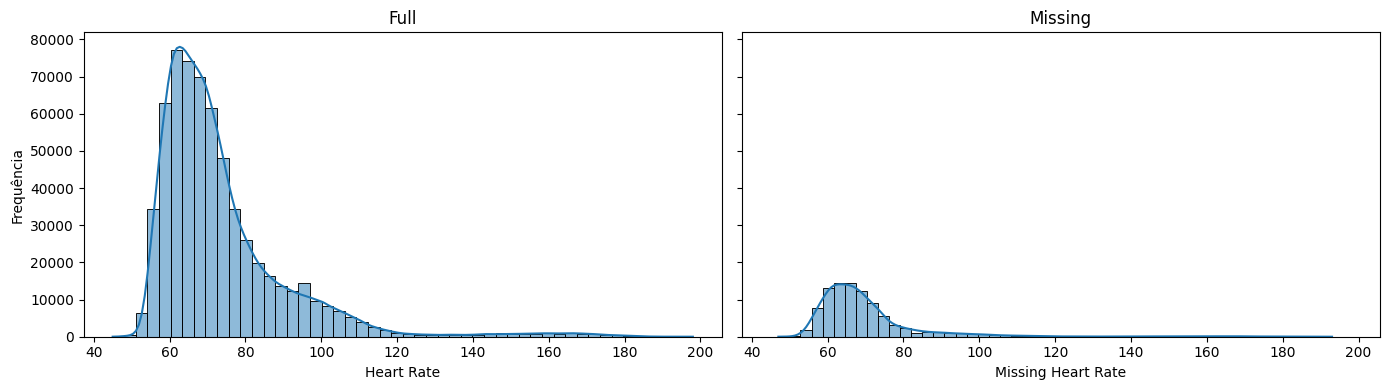

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

sns.histplot(df_mec['S1'][0]['target'], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Full")
axes[0].set_xlabel("Heart Rate")
axes[0].set_ylabel("Frequência")

sns.histplot(df_mec['S1'][0].loc[df_mec['S1'][0]["heartrate"].isna(),"target"], bins=50, kde=True, ax=axes[1])
axes[1].set_title("Missing")
axes[1].set_xlabel("Missing Heart Rate")
axes[1].set_ylabel("Frequência")

xmin = min(axes[0].get_xlim()[0], axes[1].get_xlim()[0])
xmax = max(axes[0].get_xlim()[1], axes[1].get_xlim()[1])

for ax in axes:
    ax.set_xlim(xmin, xmax)

plt.tight_layout()
plt.show()

In [7]:
df_mec_particionado = {}

for mec, lista_dfs in df_mec.items():
    rs = row_summary[mec]

    cols_idx = sorted(
        [c for c in rs.columns if c.startswith("index_")],
        key=lambda c: int(c.split("_")[1])
    )

    cortes = rs.iloc[0][cols_idx].dropna().astype(int).tolist()
    if not cortes:
        continue

    if cortes[0] != 0:
        cortes = [0] + cortes

    df_mec_particionado[mec] = []

    for df in lista_dfs:
        limites = [i for i in cortes if i < len(df)]
        if limites[-1] != len(df) - 1:
            limites.append(len(df) - 1)

        partes = [
            df.iloc[inicio:fim + 1].copy()
            for inicio, fim in zip(limites[:-1], limites[1:])
        ]
        df_mec_particionado[mec].append(partes)

A1 - Estatísticas Descritivas:
count    312336.000000
mean         73.361607
std          20.083382
min          47.000000
25%          61.000000
50%          67.000000
75%          78.000000
max         198.000000
Name: target, dtype: float64

A2 - Estatísticas Descritivas:
count    312336.000000
mean         73.832344
std          14.717679
min          45.000000
25%          64.000000
50%          70.000000
75%          79.000000
max         183.000000
Name: target, dtype: float64


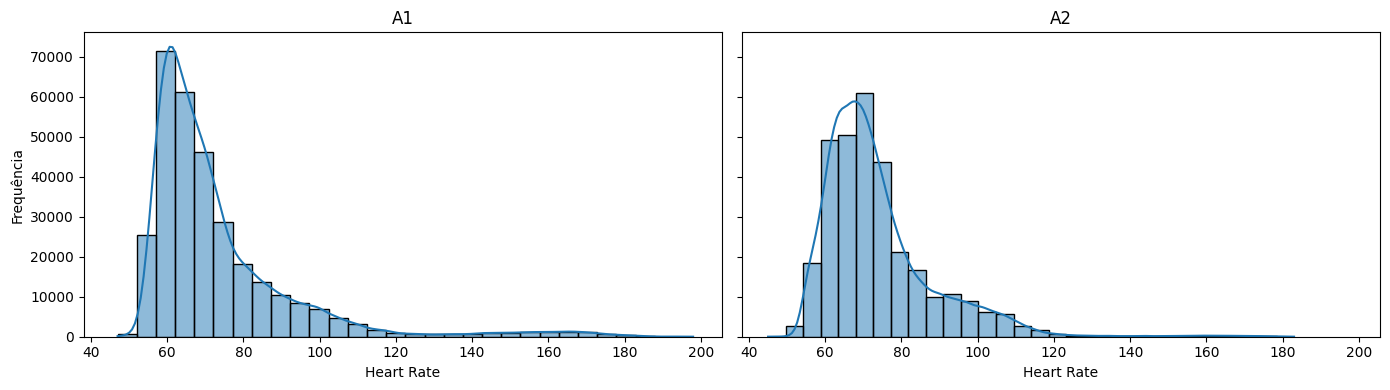

In [8]:
print("A1 - Estatísticas Descritivas:")
print(df_mec_particionado['S1'][0][0]['target'].describe())
print("\nA2 - Estatísticas Descritivas:")
print(df_mec_particionado['S1'][0][1]['target'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

sns.histplot(df_mec_particionado['S1'][0][0]['target'], bins=30, kde=True, ax=axes[0])
axes[0].set_title("A1")
axes[0].set_xlabel("Heart Rate")
axes[0].set_ylabel("Frequência")

sns.histplot(df_mec_particionado['S1'][0][1]['target'], bins=30, kde=True, ax=axes[1])
axes[1].set_title("A2")
axes[1].set_xlabel("Heart Rate")
axes[1].set_ylabel("Frequência")

xmin = min(axes[0].get_xlim()[0], axes[1].get_xlim()[0])
xmax = max(axes[0].get_xlim()[1], axes[1].get_xlim()[1])

for ax in axes:
    ax.set_xlim(xmin, xmax)

plt.tight_layout()
plt.show()

In [6]:
from scipy.stats import ks_2samp

statistic, p_value = ks_2samp(df_mec_particionado['S1'][0][0]['target'], df_mec_particionado['S1'][0][1]['target'])

print("KS statistic:", statistic)
print("p-value:", p_value)

if p_value < 0.05:
    print("Rejeitamos a hipótese nula: A1 e A2 têm distribuições diferentes.")
else:
    print("Não rejeitamos a hipótese nula: A1 e A2 podem ter a mesma distribuição.")

KS statistic: 0.13078863787715794
p-value: 0.0
Rejeitamos a hipótese nula: A1 e A2 têm distribuições diferentes.


# S1

A1 - Estatísticas Descritivas:
count    46850.000000
mean        73.349989
std         19.998307
min         47.000000
25%         61.000000
50%         67.000000
75%         78.000000
max        193.000000
Name: target, dtype: float64

A2 - Estatísticas Descritivas:
count    46850.000000
mean        66.764568
std          6.757793
min         52.000000
25%         62.000000
50%         66.000000
75%         70.000000
max        128.000000
Name: target, dtype: float64


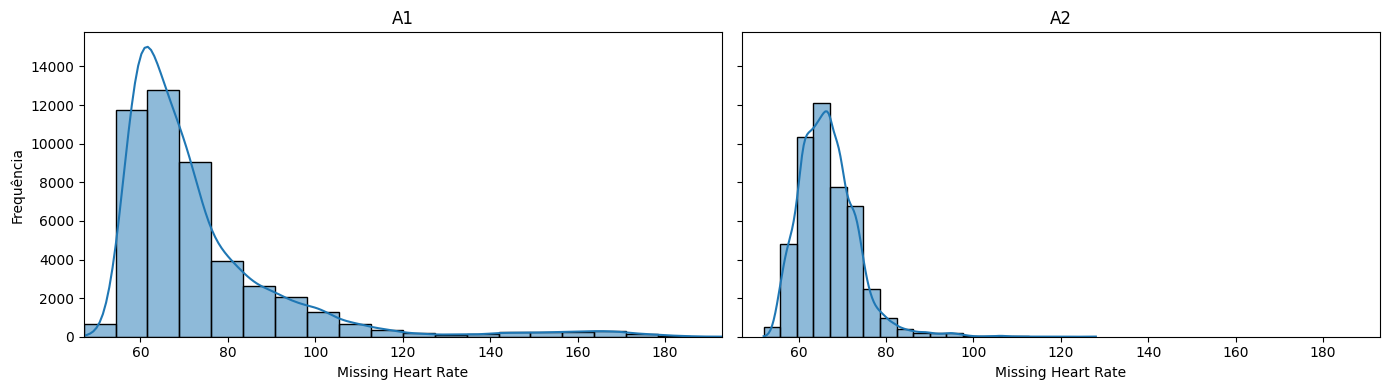

In [11]:
A1 = df_mec_particionado['S1'][0][0].loc[
    df_mec_particionado['S1'][0][0]["heartrate"].isna(),
    "target"
]
A2 = df_mec_particionado['S1'][0][1].loc[
    df_mec_particionado['S1'][0][1]["heartrate"].isna(),
    "target"
]

print("A1 - Estatísticas Descritivas:")
print(A1.describe())
print("\nA2 - Estatísticas Descritivas:")
print(A2.describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

sns.histplot(A1, bins=20, kde=True, ax=axes[0])
axes[0].set_title("A1")
axes[0].set_xlabel("Missing Heart Rate")
axes[0].set_ylabel("Frequência")

sns.histplot(A2, bins=20, kde=True, ax=axes[1])
axes[1].set_title("A2")
axes[1].set_xlabel("Missing Heart Rate")
axes[1].set_ylabel("Frequência")

xmin = min(A1.min(), A2.min())
xmax = max(A1.max(), A2.max())

for ax in axes:
    ax.set_xlim(xmin, xmax)

plt.tight_layout()
plt.show()


In [8]:
from scipy import stats

for sample, label in zip([A1, A2], ["A1", "A2"]):
    shape, loc, scale = stats.gamma.fit(sample)
    statistic, p_value = stats.kstest(sample, 'gamma', args=(shape, loc, scale))
    print(f"{label} - KS statistic: {statistic:.4f}, p-value: {p_value:.4f}")
    if p_value < 0.05:
        print(f"Rejeitamos H0: {label} não segue distribuição gama.")
    else:
        print(f"Não rejeitamos H0: {label} pode seguir distribuição gama.")
    print()

A1 - KS statistic: 0.1086, p-value: 0.0000
Rejeitamos H0: A1 não segue distribuição gama.

A2 - KS statistic: 0.0495, p-value: 0.0000
Rejeitamos H0: A2 não segue distribuição gama.



In [9]:
from scipy.stats import ks_2samp

statistic, p_value = ks_2samp(A1, A2)

print("KS statistic:", statistic)
print("p-value:", p_value)

if p_value < 0.05:
    print("Rejeitamos a hipótese nula: A1 e A2 têm distribuições diferentes.")
else:
    print("Não rejeitamos a hipótese nula: A1 e A2 podem ter a mesma distribuição.")

KS statistic: 0.20742796157950905
p-value: 0.0
Rejeitamos a hipótese nula: A1 e A2 têm distribuições diferentes.
